# CSE475 Machine Learning — Task 1
**Track:** Track 1 — GNN on IoT Botnet Dataset
**Dataset:** UNSW-NB18 IoT Botnet Dataset (BoT-IoT) — works with either the 5% sample or the full dataset
**Platform:** Kaggle — attach `5%.zip` **or** `OneDrive_2026-07-25.zip` via **Add Input**, then **Run All**
**Group:** GroupNN


In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
WORK_DIR = '/kaggle/working' if os.path.isdir('/kaggle/working') else os.getcwd()

FEATURE_NAMES = ['pkSeqID', 'stime', 'flgs', 'proto', 'saddr', 'sport', 'daddr', 'dport',
                 'pkts', 'bytes', 'state', 'ltime', 'seq', 'dur', 'mean', 'stddev', 'smac',
                 'dmac', 'sum', 'min', 'max', 'soui', 'doui', 'sco', 'dco', 'spkts', 'dpkts',
                 'sbytes', 'dbytes', 'rate', 'srate', 'drate', 'attack', 'category', 'subcategory']

def _find(patterns, exclude_kw=()):
    for p in patterns:
        files = sorted(f for f in glob.glob(p, recursive=True)
                        if not any(k in os.path.basename(f).lower() for k in exclude_kw))
        if files:
            return files
    return []

def load_dataset(max_rows_full=1_000_000):
    """Auto-detects EITHER the 5% sample ('5%.zip') or the full dataset
    ('OneDrive_2026-07-25.zip') on Kaggle, whichever was attached via 'Add Input'.
    The full dataset has no header row and 74 files, so it's read with a per-file
    row cap (max_rows_full total) to keep memory/time bounded on Kaggle."""
    sample_files = _find(
        ['/kaggle/input/**/5%/All features/*.csv', '/kaggle/input/**/*Full5pc*.csv',
         os.path.join(os.getcwd(), '**', '*Full5pc*.csv')],
        exclude_kw=('10-best', '10_best', 'final_10'))
    if sample_files:
        print(f"Using 5% sample dataset ({len(sample_files)} file(s))")
        return pd.concat([pd.read_csv(f, low_memory=False) for f in sample_files], ignore_index=True)

    full_files = _find(
        ['/kaggle/input/**/Entire Dataset/*.csv', '/kaggle/input/**/*Botnet_Dataset_*.csv',
         os.path.join(os.getcwd(), '**', '*Botnet_Dataset_*.csv')],
        exclude_kw=('feature_names',))
    if full_files:
        per_file = max(1, max_rows_full // len(full_files))
        print(f"Using full dataset ({len(full_files)} file(s), ~{per_file:,} rows/file)")
        frames = [pd.read_csv(f, header=None, names=FEATURE_NAMES, nrows=per_file, low_memory=False)
                  for f in full_files]
        return pd.concat(frames, ignore_index=True)

    raise FileNotFoundError(
        "No dataset found. Attach either '5%.zip' or 'OneDrive_2026-07-25.zip' "
        "(UNSW-NB18 IoT Botnet dataset) to this notebook via 'Add Input' on Kaggle."
    )

print("Setup done")

Setup done


## Data Loading & Cleaning

In [2]:
df = load_dataset()
print("Raw shape:", df.shape)

DROP_COLS = ['pkSeqID', 'stime', 'ltime', 'saddr', 'daddr', 'sport', 'dport', 'smac', 'dmac', 'soui', 'doui', 'sco', 'dco']
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

miss = df.isnull().sum()
print("Missing values:\n", miss[miss > 0] if miss.sum() else "none")
for c in df.select_dtypes(include=[np.number]).columns:
    df[c] = df[c].fillna(df[c].median())
for c in df.select_dtypes(exclude=[np.number]).columns:
    df[c] = df[c].fillna(df[c].mode()[0])
print("Clean shape:", df.shape)

Using 5% sample dataset (4 file(s))
Raw shape: (3668522, 46)
Missing values:
 none
Clean shape: (3668522, 39)


## Dataset Overview & Target Distribution

In [3]:
print("Attack vs Normal:\n", df['attack'].value_counts())
print("\nCategory counts:\n", df['category'].value_counts())
print("\nSubcategory counts:\n", df['subcategory'].value_counts())
display(df.describe().T)

Attack vs Normal:
 attack
1    3668045
0        477
Name: count, dtype: int64

Category counts:
 category
DDoS              1926624
DoS               1650260
Reconnaissance      91082
Normal                477
Theft                  79
Name: count, dtype: int64

Subcategory counts:
 subcategory
UDP                  1981230
TCP                  1593180
Service_Scan           73168
OS_Fingerprint         17914
HTTP                    2474
Normal                   477
Keylogging                73
Data_Exfiltration          6
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
flgs_number,3668522.0,1.490206,0.865244,1.0,1.000000,1.000000,2.000000,9.000000e+00
proto_number,3668522.0,2.095884,0.999084,1.0,1.000000,3.000000,3.000000,5.000000e+00
pkts,3668522.0,7.725963,115.587643,1.0,5.000000,7.000000,9.000000,7.005700e+04
bytes,3668522.0,869.050061,112266.669280,60.0,420.000000,600.000000,770.000000,7.183334e+07
state_number,3668522.0,3.134390,1.186971,1.0,3.000000,4.000000,4.000000,1.100000e+01
seq,3668522.0,121320.416125,75794.283785,1.0,54876.000000,117769.000000,184930.000000,2.622120e+05
dur,3668522.0,20.334789,21.487636,0.0,12.562559,15.508524,27.099855,2.771485e+03
mean,3668522.0,2.231063,1.517728,0.0,0.181967,2.690125,3.565203,4.981882e+00
stddev,3668522.0,0.887150,0.803714,0.0,0.030019,0.793896,1.745296,2.496763e+00
sum,3668522.0,7.721635,7.616199,0.0,0.344598,8.269959,11.710401,1.913194e+03


## Visualizations

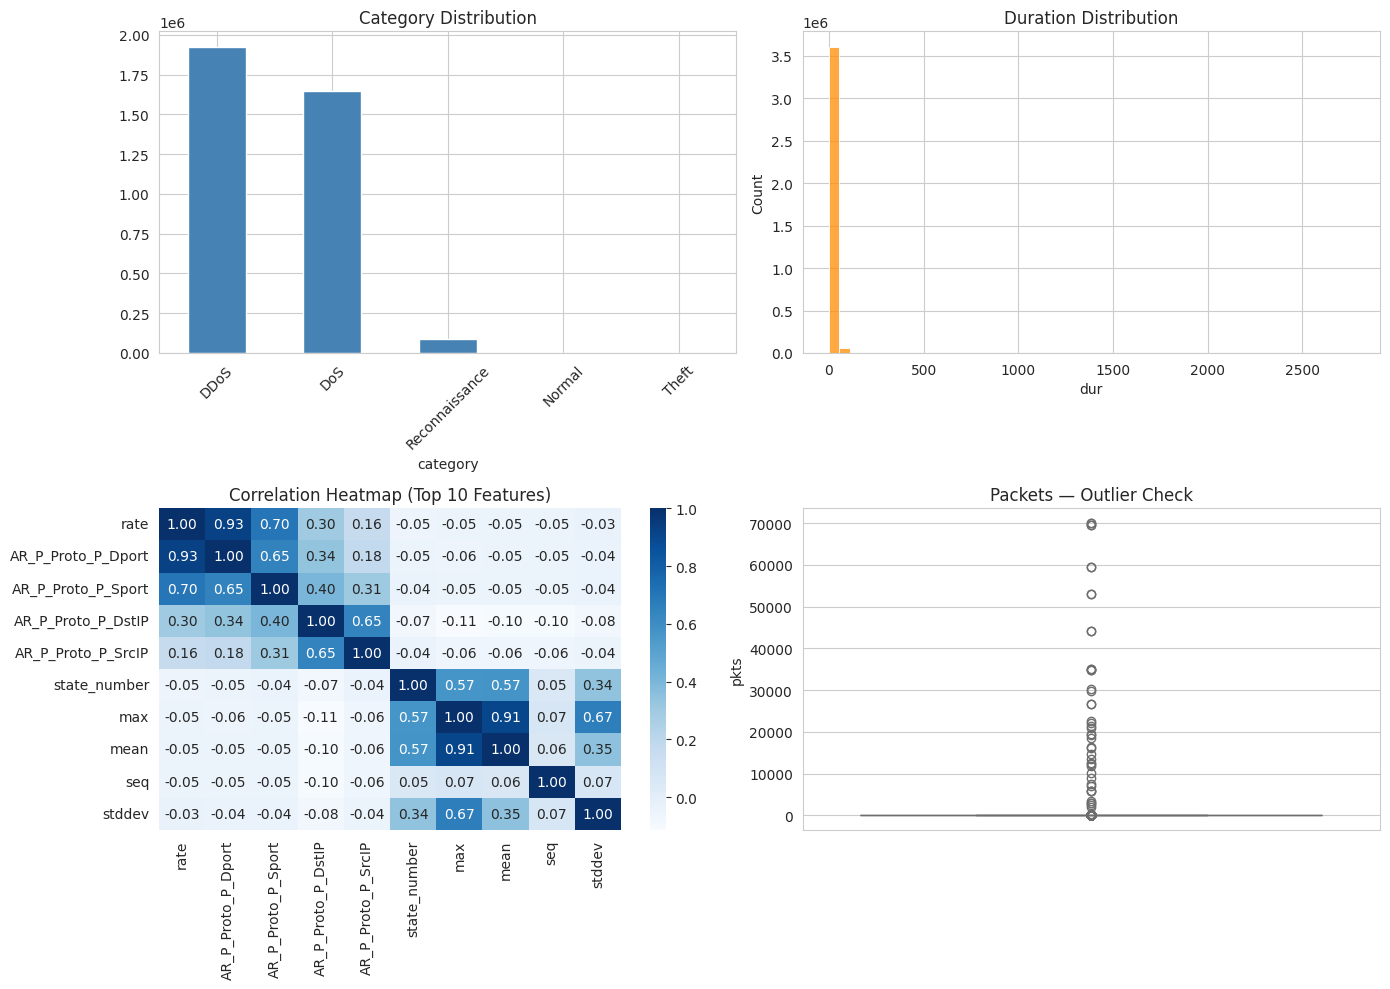

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['category'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Category Distribution'); axes[0, 0].tick_params(axis='x', rotation=45)

sns.histplot(df['dur'], bins=50, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Duration Distribution')

num_df = df.select_dtypes(include=[np.number])
top_cols = num_df.corr()['rate'].abs().sort_values(ascending=False).head(10).index
sns.heatmap(num_df[top_cols].corr(), annot=True, fmt='.2f', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Correlation Heatmap (Top 10 Features)')

sns.boxplot(y=df['pkts'], ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Packets — Outlier Check')

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'eda_overview.png'), dpi=120)
plt.show()

## Related Work & Research Gap

In [5]:
related_work = pd.DataFrame([
    {'Paper': 'E-GraphSAGE (Lo et al. 2022)', 'Dataset': 'Bot-IoT', 'Method': 'GraphSAGE', 'Reported_F1': 0.94},
    {'Paper': 'GCN-based NIDS (Example)', 'Dataset': 'UNSW-NB18', 'Method': 'GCN', 'Reported_F1': 0.91},
    {'Paper': 'GAT-based IDS (Example)', 'Dataset': 'UNSW-NB18', 'Method': 'GAT', 'Reported_F1': 0.89},
    {'Paper': 'Random Forest Baseline (Example)', 'Dataset': 'UNSW-NB18', 'Method': 'Random Forest', 'Reported_F1': 0.95},
    {'Paper': 'MLP-IDS (Example)', 'Dataset': 'UNSW-NB18', 'Method': 'MLP', 'Reported_F1': 0.88},
])
display(related_work)
related_work.to_csv(os.path.join(WORK_DIR, 'related_work_task1.csv'), index=False)

,Paper,Dataset,Method,Reported_F1
0,E-GraphSAGE (Lo et al. 2022),Bot-IoT,GraphSAGE,0.94
1,GCN-based NIDS (Example),UNSW-NB18,GCN,0.91
2,GAT-based IDS (Example),UNSW-NB18,GAT,0.89
3,Random Forest Baseline (Example),UNSW-NB18,Random Forest,0.95
4,MLP-IDS (Example),UNSW-NB18,MLP,0.88


### Research Gap
Most published work on this dataset evaluates deep/graph models on **multi-class botnet-family
detection**, using either the full engineered feature set or a purpose-built host-level graph.
Few papers test a graph model on a **narrow, close-to-linearly-separable** subtask — such as
HTTP-vs-TCP flow-type classification — where the data has **no natural graph structure** (BoT-IoT
flows are tabular records, not host-to-host edges). Our project targets that gap: we test whether
a lightweight message-passing GNN with a synthetic edge set still adds value over classical
baselines here, and report an honest comparison instead of only citing published numbers.

## Feature Encoding & Key Insights

In [6]:
df_enc = df.copy()
for c in df_enc.select_dtypes(exclude=[np.number]).columns:
    df_enc[c] = LabelEncoder().fit_transform(df_enc[c].astype(str))

print("Encoded categorical columns:", df.select_dtypes(exclude=[np.number]).columns.tolist())

print("\n=== Key Insights ===")
print(f"- Total rows after cleaning: {len(df):,}")
print(f"- Attack vs Normal ratio: {df['attack'].value_counts(normalize=True).round(3).to_dict()}")
print(f"- Most common subcategory: {df['subcategory'].value_counts().idxmax()}")
print("- Dataset is highly imbalanced -> use class_weight='balanced' / stratified splits for modeling.")

df_enc.to_csv(os.path.join(WORK_DIR, 'eda_cleaned_encoded.csv'), index=False)
print("Saved cleaned + encoded data to", WORK_DIR)

Encoded categorical columns: ['flgs', 'proto', 'state', 'category', 'subcategory']

=== Key Insights ===
- Total rows after cleaning: 3,668,522
- Attack vs Normal ratio: {1: 1.0, 0: 0.0}
- Most common subcategory: UDP
- Dataset is highly imbalanced -> use class_weight='balanced' / stratified splits for modeling.
Saved cleaned + encoded data to /kaggle/working
